## Shell Contact Example

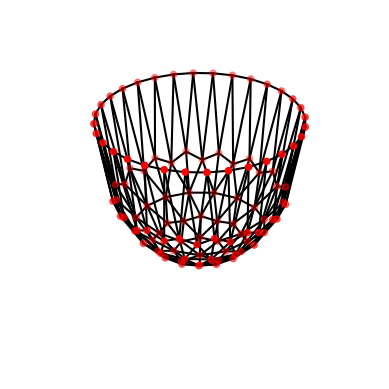

In [1]:
import numpy as np

import dismech


geom = dismech.GeomParams(rod_r0=0.005,
                          shell_h=0.001)

material = dismech.Material(density=1000,
                            youngs_rod=0,
                            youngs_shell=1e9,
                            poisson_rod=0,
                            poisson_shell=0.5)

shell_contact_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=False,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=True,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-3,
                                  max_iter=120,
                                  total_time=2.5,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2,
                                  use_predictor_corrector_for_ground_contact=True,
                                  no_future_freeing_after_ground_contact=True,
                                  frictionless_pc_contact=True
                                )

env = dismech.Environment()
# env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
env.add_force('floorContact', ground_z=-1, stiffness=50, delta=1e-3, h=1e-3)
# env.add_force('selfContact', delta=1e-4, h=1e-3, kc=1)
env.add_force('damping', eta = 0.05)
#env.set_static()   

geo = dismech.Geometry.from_txt('../tests/resources/shell_contact/input_hemisphere_more_dense_inverted.txt')

robot = dismech.SoftRobot(geom, material, geo, shell_contact_sim, env)


fixed_points = np.array(np.where(
    (robot.state.q[:robot.end_node_dof_index].reshape(-1, 3)[:, 2] > -0.001) # (robot.state.q[:robot.end_node_dof_index].reshape(-1, 3)[:, 2] < 0.001)
)[0])

robot = robot.fix_nodes(fixed_points)



### Time Stepping

In [2]:
# before step function
# move the fixed nodes towards the ground with uniform speed

def push_into_ground(robot, t):
    # slowly increase the displacement of the last node to the right
    """ Simple example of a moving boundary condition """
        # [x, y, z]
    u0 = 0.1
        # [x, y, z]
    robot = robot.move_nodes(fixed_points, [0, 0, -u0 * robot.sim_params.dt])
    
    return robot

stepper = dismech.ImplicitEulerTimeStepper(robot)
stepper.before_step = push_into_ground

In [3]:
robots, t_arr, f_norms, Fs = stepper.simulate()

qs = np.stack([r.state.q for r in robots])
t_arr = np.array(t_arr[:len(qs)])

iter: 1, error: 912.905
iter: 2, error: 0.052
iter: 1, error: 964.364
iter: 2, error: 0.093
current_time:  0.001
iter: 1, error: 987.030
iter: 2, error: 0.137
current_time:  0.002
iter: 1, error: 962.077
iter: 2, error: 0.107
current_time:  0.003
iter: 1, error: 952.709
iter: 2, error: 0.079
current_time:  0.004
iter: 1, error: 951.911
iter: 2, error: 0.068
current_time:  0.005
iter: 1, error: 952.693
iter: 2, error: 0.067
current_time:  0.006
iter: 1, error: 953.151
iter: 2, error: 0.068
current_time:  0.007
iter: 1, error: 953.212
iter: 2, error: 0.070
current_time:  0.008
iter: 1, error: 953.130
iter: 2, error: 0.072
current_time:  0.009000000000000001
iter: 1, error: 953.061
iter: 2, error: 0.074
current_time:  0.010000000000000002
iter: 1, error: 953.036
iter: 2, error: 0.076
current_time:  0.011000000000000003
iter: 1, error: 953.034
iter: 2, error: 0.077
current_time:  0.012000000000000004
iter: 1, error: 953.039
iter: 2, error: 0.078
current_time:  0.013000000000000005
iter: 1,

In [4]:
options = dismech.AnimationOptions(
    title='Predictor-Corrector Hemisphere Contact',
    # z_lim=(robot.env.ground_z + robot.env.ground_h - 1e-3,
    #        qs[:, 2::3].max() + 1e-3),
    plot_step=100
)

fixed_dof_history = [r.fixed_dof for r in robots]   # <-- new
fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options,
                            fixed_dof_history=fixed_dof_history)
fig.show()

27


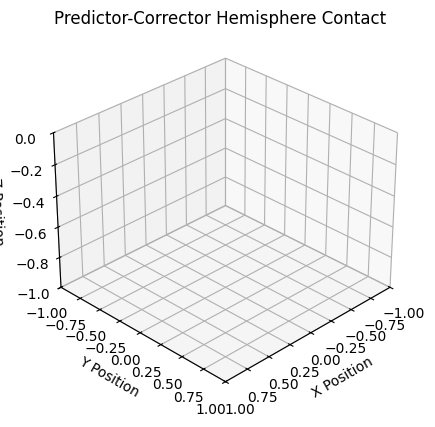

In [5]:
ani = dismech.get_animation(robot, t_arr, qs, options, fixed_dof_history=fixed_dof_history)
ani.save('predictor_corrector.gif')

In [6]:
# print("fixed_dof_history: ", fixed_dof_history)

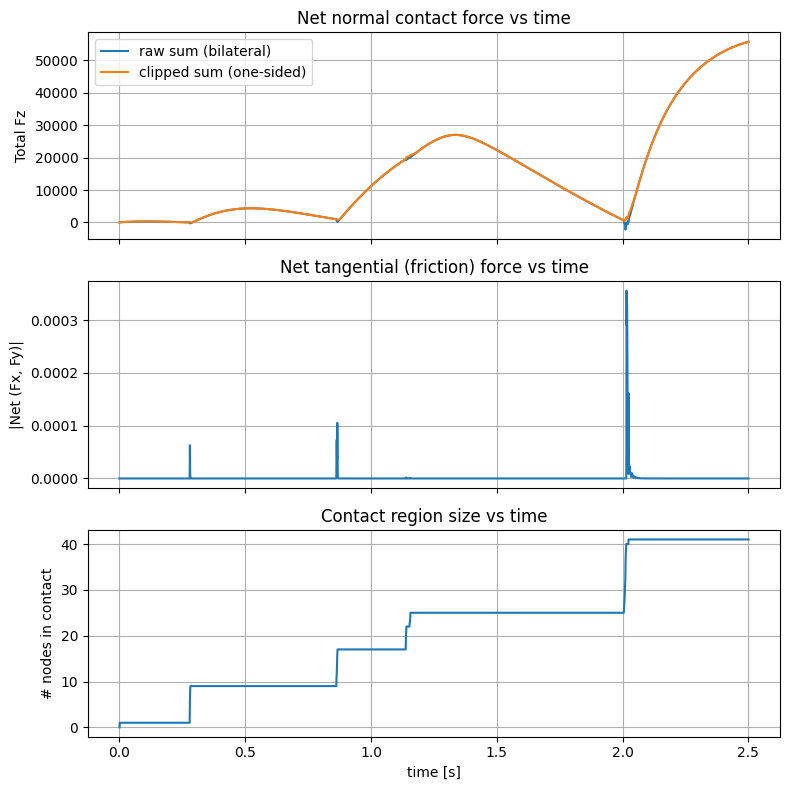

In [7]:
import matplotlib.pyplot as plt

# stepper.contact_log was populated by simulate() at the same cadence as Fs/t_arr.
# Each entry is (node_indices, F_xyz) where F_xyz has shape (N, 3) with columns
# [Fx, Fy, Fz] — the Newton residual at each contact-pinned node's x/y/z DOFs.
# Fz is the normal reaction; Fx, Fy are ~0 for sliding (z-only pinned) nodes
# and the friction reactions for nodes the corrector fully constrained.
contact_log = stepper.contact_log[:len(t_arr)]

# Net z-direction contact force = sum of Fz over all currently in-contact nodes.
# With no_future_freeing=True the z-constraint is bilateral, so individual
# F_xyz[:, 2] entries can be negative (constraint pulling a node down) and
# cancel against positive entries at nodes the ground is actually pushing up.
contact_force_z = np.array([
    float(F_xyz[:, 2].sum()) if F_xyz.size > 0 else 0.0
    for (_, F_xyz) in contact_log
])

# One-sided normal reaction: clip negative per-node Fz to zero before summing,
# so only nodes the constraint is actively pushing UP contribute. This matches
# what a unilateral (real) ground contact would report.
contact_force_z_pos = np.array([
    float(np.maximum(F_xyz[:, 2], 0.0).sum()) if F_xyz.size > 0 else 0.0
    for (_, F_xyz) in contact_log
])

# Net in-plane friction magnitude = |sum of (Fx, Fy) over all in-contact nodes|.
# Only nonzero for nodes the corrector fully constrained (stuck).
friction_force_xy = np.array([
    float(np.linalg.norm(F_xyz[:, :2].sum(axis=0))) if F_xyz.size > 0 else 0.0
    for (_, F_xyz) in contact_log
])

# Contact region size = number of nodes whose z-DOF is currently pinned.
n_contact_nodes = np.array([nodes.size for (nodes, _) in contact_log])

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t_arr, contact_force_z, label="raw sum (bilateral)")
axes[0].plot(t_arr, contact_force_z_pos, label="clipped sum (one-sided)")
axes[0].set_ylabel("Total Fz")
axes[0].set_title("Net normal contact force vs time")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_arr, friction_force_xy)
axes[1].set_ylabel("|Net (Fx, Fy)|")
axes[1].set_title("Net tangential (friction) force vs time")
axes[1].grid(True)

axes[2].plot(t_arr, n_contact_nodes)
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("# nodes in contact")
axes[2].set_title("Contact region size vs time")
axes[2].grid(True)

plt.tight_layout()
plt.show()


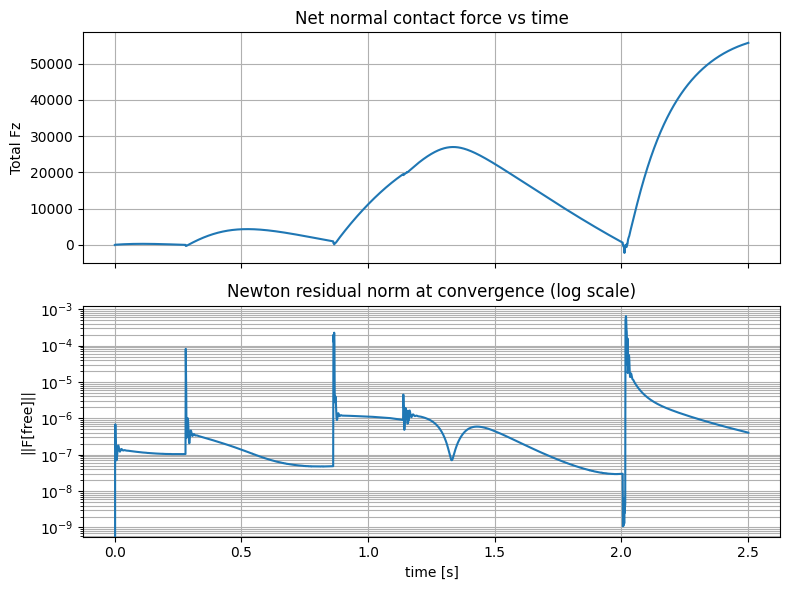

In [8]:
import matplotlib.pyplot as plt

f_norms_arr = np.array(f_norms[:len(t_arr)])

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(t_arr, contact_force_z)
axes[0].set_ylabel("Total Fz")
axes[0].set_title("Net normal contact force vs time")
axes[0].grid(True)

axes[1].semilogy(t_arr, f_norms_arr)
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("||F[free]||")
axes[1].set_title("Newton residual norm at convergence (log scale)")
axes[1].grid(True, which="both")

plt.tight_layout()
plt.show()


In [9]:
import numpy as np

# Index of the t≈0.85s dip (or any dip you want to inspect)
i_dip = int(np.argmin(np.abs(t_arr - 0.85)))

for i in (i_dip - 1, i_dip, i_dip + 1):
    nodes_i, F_xyz_i = contact_log[i]
    Fz_i = F_xyz_i[:, 2]
    print(f"t = {t_arr[i]:.4f} s | n_contacts = {nodes_i.size:3d} | "
          f"sum Fz = {Fz_i.sum():.3f} | "
          f"min/max per-node Fz = {Fz_i.min():.3f} / {Fz_i.max():.3f}")


t = 0.8490 s | n_contacts =   9 | sum Fz = 1161.533 | min/max per-node Fz = -0.289 / 151.847
t = 0.8500 s | n_contacts =   9 | sum Fz = 1148.740 | min/max per-node Fz = -0.291 / 150.240
t = 0.8510 s | n_contacts =   9 | sum Fz = 1135.955 | min/max per-node Fz = -0.292 / 148.634


In [10]:
def fmt(Fz):
    if Fz.size == 0:
        return "sumFz=    0.000  min=  empty  max=  empty"
    return f"sumFz={Fz.sum():9.3f}  min={Fz.min():8.3f}  max={Fz.max():8.3f}"

jumps = np.where(np.diff(n_contact_nodes) > 0)[0] + 1

for i in jumps:
    for j in (i - 1, i, i + 1):
        nodes_j, F_xyz_j = contact_log[j]
        Fz_j = F_xyz_j[:, 2]
        tag = "BEFORE" if j == i - 1 else ("AT JUMP" if j == i else "AFTER")
        print(f"  {tag:7s} t={t_arr[j]:.4f}  n={nodes_j.size:3d}  {fmt(Fz_j)}")
    print()


  BEFORE  t=0.0000  n=  0  sumFz=    0.000  min=  empty  max=  empty
  AT JUMP t=0.0010  n=  1  sumFz=   65.701  min=  65.701  max=  65.701
  AFTER   t=0.0020  n=  1  sumFz=   63.356  min=  63.356  max=  63.356

  BEFORE  t=0.2790  n=  1  sumFz=   24.948  min=  24.948  max=  24.948
  AT JUMP t=0.2800  n=  6  sumFz= -259.813  min= -70.967  max=   9.365
  AFTER   t=0.2810  n=  8  sumFz= -292.767  min= -63.446  max=   3.418

  BEFORE  t=0.2800  n=  6  sumFz= -259.813  min= -70.967  max=   9.365
  AT JUMP t=0.2810  n=  8  sumFz= -292.767  min= -63.446  max=   3.418
  AFTER   t=0.2820  n=  9  sumFz= -254.179  min= -39.342  max=   0.791

  BEFORE  t=0.2810  n=  8  sumFz= -292.767  min= -63.446  max=   3.418
  AT JUMP t=0.2820  n=  9  sumFz= -254.179  min= -39.342  max=   0.791
  AFTER   t=0.2830  n=  9  sumFz= -222.608  min= -41.574  max=   0.789

  BEFORE  t=0.8620  n=  9  sumFz=  995.901  min=  -0.311  max= 131.040
  AT JUMP t=0.8630  n= 11  sumFz=  569.710  min=-198.801  max= 128.999
  AF

In [11]:
print(f"  {'t':>8s}  {'n':>3s}  {'sumFz':>10s}  {'pos_sum':>10s}  {'neg_sum':>10s}")
for i in jumps:
    nodes_i, F_xyz_i = contact_log[i]
    Fz_i = F_xyz_i[:, 2]
    pos = Fz_i[Fz_i > 0].sum()
    neg = Fz_i[Fz_i < 0].sum()
    print(f"  {t_arr[i]:8.4f}  {nodes_i.size:3d}  "
          f"{Fz_i.sum():10.3f}  {pos:10.3f}  {neg:10.3f}")


         t    n       sumFz     pos_sum     neg_sum
    0.0010    1      65.701      65.701       0.000
    0.2800    6    -259.813       9.365    -269.178
    0.2810    8    -292.767       3.418    -296.186
    0.2820    9    -254.179       0.791    -254.970
    0.8630   11     569.710     967.083    -397.373
    0.8640   12     620.362     940.693    -320.331
    0.8650   14     313.048     910.945    -597.897
    0.8660   16     142.531     878.339    -735.808
    0.8670   17     242.426     856.497    -614.071
    1.1390   20   19260.849   19852.505    -591.656
    1.1400   21   19326.762   20033.199    -706.437
    1.1410   22   19330.512   20177.000    -846.488
    1.1540   23   20008.716   20579.749    -571.033
    1.1560   24   20081.138   20719.005    -637.866
    1.1570   25   20086.693   20832.967    -746.274
    2.0060   26     -83.030     572.290    -655.320
    2.0070   27    -126.298     515.873    -642.171
    2.0080   28    -371.966     452.838    -824.804
    2.0090  

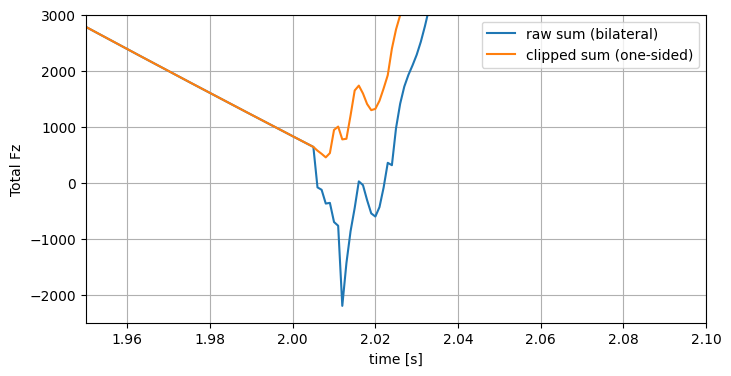

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_arr, contact_force_z,     label="raw sum (bilateral)")
ax.plot(t_arr, contact_force_z_pos, label="clipped sum (one-sided)")
ax.set_xlim(1.95, 2.10)
ax.set_ylim(-2500, 3000)
ax.set_xlabel("time [s]"); ax.set_ylabel("Total Fz"); ax.legend(); ax.grid(True)
plt.show()
